<font color="#CA0032"><h1 align="left">**Entradas heterogéneas**</h1></font>

<font color="#6E6E6E"><h1 align="left">**Predicción de ventas Rossmann**</h1></font>

<h2 align="left">Práctica B3—T5</h2>

**Componentes del grupo:**

- Josep Pérez Segura
- Natalia San José Ortega
- Emilio Sanchez Martínez

### **Objetivo**

Construir un modelo neuronal para predicción de ventas usando entradas heterogéneas: series temporales de ventas, variables exógenas conocidas y atributos estáticos de cada tienda.

In [16]:
COLAB = False

## <font color="#CA3532"> **1. Importar librerías**

In [17]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from IPython.display import display

In [18]:
# Fijo la semilla aleatoria por reproducibilidad.
np.random.seed(7)

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)

## <font color="#CA3532"> **2. Carga y unión de datos**

Los datos de Rossmann se distribuyen en tres ficheros principales:

- `train.csv`: histórico diario de ventas por tienda.
- `test.csv`: registros para los que se generará predicción.
- `store.csv`: información estática de cada tienda.

In [19]:
DATASET_DIR = Path("dataset_completo_Rossmann-20260604T174330Z-3-001") / "dataset_completo_Rossmann"

if not DATASET_DIR.exists():
    candidates = sorted(Path(".").glob("**/dataset_completo_Rossmann"))
    if not candidates:
        raise FileNotFoundError("No se ha encontrado la carpeta dataset_completo_Rossmann")
    DATASET_DIR = candidates[0]

DATASET_DIR

WindowsPath('dataset_completo_Rossmann-20260604T174330Z-3-001/dataset_completo_Rossmann')

In [20]:
train_path = DATASET_DIR / "train.csv"
test_path = DATASET_DIR / "test.csv"
store_path = DATASET_DIR / "store.csv"
submission_path = DATASET_DIR / "submission.csv"

for path in [train_path, test_path, store_path, submission_path]:
    if not path.exists():
        raise FileNotFoundError(f"No se ha encontrado el fichero: {path}")

In [21]:
date_columns = ["Date"]

train = pd.read_csv(train_path, parse_dates=date_columns, low_memory=False)
test = pd.read_csv(test_path, parse_dates=date_columns, low_memory=False)
store = pd.read_csv(store_path, low_memory=False)
submission = pd.read_csv(submission_path)

print("train:", train.shape)
print("test:", test.shape)
print("store:", store.shape)
print("submission:", submission.shape)

train: (1001599, 10)
test: (1115, 9)
store: (1115, 10)
submission: (1115, 2)


In [22]:
display(train.head())
display(test.head())
display(store.head())

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001
4,5,5,2015-07-17,4355,513,1,1,0,1,981931


,Id,Store,DayOfWeek,Date,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,879066,1,5,2015-07-31,555,1,1,0,1
1,37135,2,5,2015-07-31,625,1,1,0,1
2,285919,3,5,2015-07-31,821,1,1,0,1
3,744348,4,5,2015-07-31,1498,1,1,0,1
4,556250,5,5,2015-07-31,559,1,1,0,1


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.000,9.000,2008.000,0,NaN,NaN,NaN
1,2,a,a,570.000,11.000,2007.000,1,13.000,2010.000,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.000,12.000,2006.000,1,14.000,2011.000,"Jan,Apr,Jul,Oct"
3,4,c,c,620.000,9.000,2009.000,0,NaN,NaN,NaN
4,5,a,a,29910.000,4.000,2015.000,0,NaN,NaN,NaN


### **Revisión básica de estructura**

In [23]:
def resumen_dataframe(df, nombre):
    return pd.Series({
        "filas": len(df),
        "columnas": df.shape[1],
        "tiendas": df["Store"].nunique() if "Store" in df else np.nan,
        "fecha_min": df["Date"].min() if "Date" in df else pd.NaT,
        "fecha_max": df["Date"].max() if "Date" in df else pd.NaT,
        "duplicados": df.duplicated().sum(),
    }, name=nombre)

resumen = pd.concat([
    resumen_dataframe(train, "train"),
    resumen_dataframe(test, "test"),
    resumen_dataframe(store, "store"),
], axis=1).T

resumen

,filas,columnas,tiendas,fecha_min,fecha_max,duplicados
train,1001599,10,1115,2013-01-01 00:00:00,2015-07-17 00:00:00,0
test,1115,9,1115,2015-07-31 00:00:00,2015-07-31 00:00:00,0
store,1115,10,1115,NaT,NaT,0


In [24]:
nulos = pd.concat({
    "train": train.isna().sum(),
    "test": test.isna().sum(),
    "store": store.isna().sum(),
}, axis=1).fillna(0).astype(int)

nulos[nulos.sum(axis=1) > 0]

,train,test,store
CompetitionDistance,0,0,3
CompetitionOpenSinceMonth,0,0,354
CompetitionOpenSinceYear,0,0,354
Promo2SinceWeek,0,0,544
Promo2SinceYear,0,0,544
PromoInterval,0,0,544


### **Normalización inicial de tipos**

Antes de unir las tablas, se normalizan algunas variables categóricas para evitar inconsistencias entre `train`, `test` y `store`.

In [25]:
def normalizar_state_holiday(df):
    df = df.copy()
    df["StateHoliday"] = df["StateHoliday"].astype(str).replace({"0.0": "0"})
    return df


def ordenar_por_tienda_y_fecha(df):
    return df.sort_values(["Store", "Date"]).reset_index(drop=True)


train = normalizar_state_holiday(train)
test = normalizar_state_holiday(test)

train = ordenar_por_tienda_y_fecha(train)
test = ordenar_por_tienda_y_fecha(test)
store = store.sort_values("Store").reset_index(drop=True)

### **Unión con atributos de tienda**

In [26]:
if store["Store"].duplicated().any():
    raise ValueError("store.csv contiene tiendas duplicadas")

train_full = train.merge(store, on="Store", how="left", validate="many_to_one")
test_full = test.merge(store, on="Store", how="left", validate="many_to_one")

print("train_full:", train_full.shape)
print("test_full:", test_full.shape)

train_full: (1001599, 19)
test_full: (1115, 18)


In [27]:
columnas_sin_info_tienda = [
    col for col in store.columns
    if col != "Store" and train_full[col].isna().all()
]

if columnas_sin_info_tienda:
    raise ValueError(f"Columnas de tienda sin información tras el merge: {columnas_sin_info_tienda}")

display(train_full.head())
display(test_full.head())

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2,2013-01-01,0,0,0,0,a,1,690197,c,a,1270.000,9.000,2008.000,0,NaN,NaN,NaN
1,1,3,2013-01-02,5530,668,1,0,0,1,988300,c,a,1270.000,9.000,2008.000,0,NaN,NaN,NaN
2,1,4,2013-01-03,4327,578,1,0,0,1,919910,c,a,1270.000,9.000,2008.000,0,NaN,NaN,NaN
3,1,5,2013-01-04,4486,619,1,0,0,1,662609,c,a,1270.000,9.000,2008.000,0,NaN,NaN,NaN
4,1,6,2013-01-05,4997,635,1,0,0,1,1008092,c,a,1270.000,9.000,2008.000,0,NaN,NaN,NaN


,Id,Store,DayOfWeek,Date,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,879066,1,5,2015-07-31,555,1,1,0,1,c,a,1270.000,9.000,2008.000,0,NaN,NaN,NaN
1,37135,2,5,2015-07-31,625,1,1,0,1,a,a,570.000,11.000,2007.000,1,13.000,2010.000,"Jan,Apr,Jul,Oct"
2,285919,3,5,2015-07-31,821,1,1,0,1,a,a,14130.000,12.000,2006.000,1,14.000,2011.000,"Jan,Apr,Jul,Oct"
3,744348,4,5,2015-07-31,1498,1,1,0,1,c,c,620.000,9.000,2009.000,0,NaN,NaN,NaN
4,556250,5,5,2015-07-31,559,1,1,0,1,a,a,29910.000,4.000,2015.000,0,NaN,NaN,NaN


### **Variables de calendario**

Se añaden variables derivadas de la fecha que podrán usarse como entradas exógenas conocidas antes del día de predicción.

In [28]:
def crear_variables_calendario(df):
    df = df.copy()
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["DayOfYear"] = df["Date"].dt.dayofyear
    return df


train_full = crear_variables_calendario(train_full)
test_full = crear_variables_calendario(test_full)

In [29]:
columnas_base = [
    "Store", "Date", "Sales", "Customers", "Open", "Promo",
    "StateHoliday", "SchoolHoliday", "StoreType", "Assortment",
    "CompetitionDistance", "Promo2", "Year", "Month", "DayOfWeek",
    "WeekOfYear", "DayOfYear",
]

display(train_full[columnas_base].head(10))

,Store,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Year,Month,DayOfWeek,WeekOfYear,DayOfYear
0,1,2013-01-01,0,0,0,0,a,1,c,a,1270.000,0,2013,1,2,1,1
1,1,2013-01-02,5530,668,1,0,0,1,c,a,1270.000,0,2013,1,3,1,2
2,1,2013-01-03,4327,578,1,0,0,1,c,a,1270.000,0,2013,1,4,1,3
3,1,2013-01-04,4486,619,1,0,0,1,c,a,1270.000,0,2013,1,5,1,4
4,1,2013-01-05,4997,635,1,0,0,1,c,a,1270.000,0,2013,1,6,1,5
5,1,2013-01-06,0,0,0,0,0,1,c,a,1270.000,0,2013,1,7,1,6
6,1,2013-01-07,7176,785,1,1,0,1,c,a,1270.000,0,2013,1,1,2,7
7,1,2013-01-08,5580,654,1,1,0,1,c,a,1270.000,0,2013,1,2,2,8
8,1,2013-01-09,5471,626,1,1,0,1,c,a,1270.000,0,2013,1,3,2,9
9,1,2013-01-10,4892,615,1,1,0,1,c,a,1270.000,0,2013,1,4,2,10


### **Resumen para el modelado**

In [30]:
variables_endogenas = ["Sales"]
variables_exogenas_temporales = [
    "Customers", "Open", "Promo", "StateHoliday", "SchoolHoliday",
    "DayOfWeek", "Month", "WeekOfYear", "DayOfYear",
]
variables_estaticas_tienda = [
    "Store", "StoreType", "Assortment", "CompetitionDistance",
    "CompetitionOpenSinceMonth", "CompetitionOpenSinceYear",
    "Promo2", "Promo2SinceWeek", "Promo2SinceYear", "PromoInterval",
]

pd.DataFrame({
    "tipo": [
        "endógenas",
        "exógenas temporales",
        "estáticas de tienda",
    ],
    "variables": [
        variables_endogenas,
        variables_exogenas_temporales,
        variables_estaticas_tienda,
    ],
})

,tipo,variables
0,endógenas,[Sales]
1,exógenas temporales,"[Customers, Open, Promo, StateHoliday, SchoolH..."
2,estáticas de tienda,"[Store, StoreType, Assortment, CompetitionDist..."


## <font color="#CA3532"> **3. Limpieza avanzada y variables temporales**

En este bloque se preparan variables útiles para el modelado: tratamiento inicial de nulos, variables de competencia, variables de promoción continuada y codificación básica de categorías. El objetivo es dejar una tabla limpia antes del enventanado temporal.

In [31]:
def limpiar_variables_tienda(df, distancia_mediana=None):
    df = df.copy()

    if distancia_mediana is None:
        distancia_mediana = df["CompetitionDistance"].median()

    df["CompetitionDistance"] = df["CompetitionDistance"].fillna(distancia_mediana)
    df["PromoInterval"] = df["PromoInterval"].fillna("None")

    columnas_categoricas = ["StateHoliday", "StoreType", "Assortment", "PromoInterval"]
    for columna in columnas_categoricas:
        df[columna] = df[columna].fillna("Unknown").astype(str)

    columnas_numericas_con_nulos = [
        "CompetitionOpenSinceMonth", "CompetitionOpenSinceYear",
        "Promo2SinceWeek", "Promo2SinceYear",
    ]
    for columna in columnas_numericas_con_nulos:
        df[columna] = df[columna].fillna(0).astype(int)

    return df, distancia_mediana


train_full, distancia_mediana = limpiar_variables_tienda(train_full)
test_full, _ = limpiar_variables_tienda(test_full, distancia_mediana=distancia_mediana)

distancia_mediana

np.float64(2330.0)

### **Variables de competencia**

`CompetitionOpenSinceMonth` y `CompetitionOpenSinceYear` indican desde cuándo hay competencia cercana. Se transforman en una variable temporal más directa: meses desde que abrió la competencia.

In [32]:
def crear_variables_competencia(df):
    df = df.copy()

    hay_fecha_competencia = (
        (df["CompetitionOpenSinceMonth"] > 0)
        & (df["CompetitionOpenSinceYear"] > 0)
    )

    meses_desde_competencia = (
        (df["Year"] - df["CompetitionOpenSinceYear"]) * 12
        + (df["Month"] - df["CompetitionOpenSinceMonth"])
    )

    df["CompetitionOpen"] = hay_fecha_competencia.astype(int)
    df["CompetitionOpenMonths"] = meses_desde_competencia.where(hay_fecha_competencia, 0)
    df["CompetitionOpenMonths"] = df["CompetitionOpenMonths"].clip(lower=0)

    return df


train_full = crear_variables_competencia(train_full)
test_full = crear_variables_competencia(test_full)

train_full[[
    "Store", "Date", "CompetitionDistance", "CompetitionOpen",
    "CompetitionOpenSinceMonth", "CompetitionOpenSinceYear",
    "CompetitionOpenMonths",
]].head(10)

,Store,Date,CompetitionDistance,CompetitionOpen,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,CompetitionOpenMonths
0,1,2013-01-01,1270.000,1,9,2008,52
1,1,2013-01-02,1270.000,1,9,2008,52
2,1,2013-01-03,1270.000,1,9,2008,52
3,1,2013-01-04,1270.000,1,9,2008,52
4,1,2013-01-05,1270.000,1,9,2008,52
5,1,2013-01-06,1270.000,1,9,2008,52
6,1,2013-01-07,1270.000,1,9,2008,52
7,1,2013-01-08,1270.000,1,9,2008,52
8,1,2013-01-09,1270.000,1,9,2008,52
9,1,2013-01-10,1270.000,1,9,2008,52


### **Variables de promoción continuada**

`Promo2` indica si una tienda participa en una promoción continuada. A partir de sus columnas asociadas se crean dos variables: semanas desde el inicio de `Promo2` y si la promoción está activa en el mes del registro.

In [33]:
MESES_PROMO = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sept", 10: "Oct", 11: "Nov", 12: "Dec",
}


def crear_variables_promo2(df):
    df = df.copy()

    hay_inicio_promo2 = (
        (df["Promo2"] == 1)
        & (df["Promo2SinceWeek"] > 0)
        & (df["Promo2SinceYear"] > 0)
    )

    inicio_promo2 = pd.to_datetime(
        df["Promo2SinceYear"].astype(str)
        + df["Promo2SinceWeek"].astype(str).str.zfill(2)
        + "1",
        format="%G%V%u",
        errors="coerce",
    )

    semanas_promo2 = ((df["Date"] - inicio_promo2).dt.days // 7).where(hay_inicio_promo2, 0)
    df["Promo2Weeks"] = semanas_promo2.fillna(0).clip(lower=0).astype(int)

    mes_actual = df["Month"].map(MESES_PROMO)
    df["Promo2ActiveMonth"] = [
        int(promo2 == 1 and mes in intervalo.split(","))
        for promo2, mes, intervalo in zip(df["Promo2"], mes_actual, df["PromoInterval"])
    ]

    return df


train_full = crear_variables_promo2(train_full)
test_full = crear_variables_promo2(test_full)

train_full[[
    "Store", "Date", "Promo2", "Promo2SinceWeek", "Promo2SinceYear",
    "PromoInterval", "Promo2Weeks", "Promo2ActiveMonth",
]].head(10)

,Store,Date,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Promo2Weeks,Promo2ActiveMonth
0,1,2013-01-01,0,0,0,None,0,0
1,1,2013-01-02,0,0,0,None,0,0
2,1,2013-01-03,0,0,0,None,0,0
3,1,2013-01-04,0,0,0,None,0,0
4,1,2013-01-05,0,0,0,None,0,0
5,1,2013-01-06,0,0,0,None,0,0
6,1,2013-01-07,0,0,0,None,0,0
7,1,2013-01-08,0,0,0,None,0,0
8,1,2013-01-09,0,0,0,None,0,0
9,1,2013-01-10,0,0,0,None,0,0


### **Códigos categóricos para embeddings**

Las variables categóricas se convierten a índices enteros. Estos índices podrán usarse después como entrada de capas `Embedding`.

In [34]:
def crear_codigos_categoricos(train_df, test_df, columnas):
    train_df = train_df.copy()
    test_df = test_df.copy()
    cardinalidades = {}

    for columna in columnas:
        categorias = pd.Index(
            pd.concat([train_df[columna], test_df[columna]], ignore_index=True)
            .astype(str)
            .unique()
        ).sort_values()

        mapa = {categoria: codigo for codigo, categoria in enumerate(categorias)}
        columna_codigo = f"{columna}Code"

        train_df[columna_codigo] = train_df[columna].astype(str).map(mapa).astype(int)
        test_df[columna_codigo] = test_df[columna].astype(str).map(mapa).astype(int)
        cardinalidades[columna_codigo] = len(categorias)

    return train_df, test_df, cardinalidades


columnas_categoricas_embedding = [
    "Store", "DayOfWeek", "StateHoliday", "StoreType", "Assortment", "PromoInterval",
]

train_full, test_full, cardinalidades_embedding = crear_codigos_categoricos(
    train_full,
    test_full,
    columnas_categoricas_embedding,
)

cardinalidades_embedding

{'StoreCode': 1115,
 'DayOfWeekCode': 7,
 'StateHolidayCode': 4,
 'StoreTypeCode': 4,
 'AssortmentCode': 3,
 'PromoIntervalCode': 4}

## <font color="#CA3532"> **4. Enventanado temporal por tienda**

El enventanado se hace tienda a tienda para no mezclar el final de una serie temporal con el inicio de otra. Cada muestra contiene los últimos `lookback` días de información y el objetivo es `Sales` en el día siguiente.

In [35]:
columnas_temporales_ventana = [
    "Sales", "Customers", "Open", "Promo", "SchoolHoliday",
    "CompetitionDistance", "CompetitionOpenMonths",
    "Promo2Weeks", "Promo2ActiveMonth",
    "DayOfWeek", "Month", "WeekOfYear", "DayOfYear",
]

columnas_estaticas_ventana = [
    "StoreCode", "StoreTypeCode", "AssortmentCode", "PromoIntervalCode",
    "CompetitionDistance", "CompetitionOpen", "Promo2",
]

target = "Sales"
lookback = 28
horizonte = 1

# Para desarrollar y validar el flujo usamos 10 tiendas.
# Cambiar a None para generar ventanas de todas las tiendas.
tiendas_desarrollo = sorted(train_full["Store"].unique())[:10]

In [36]:
if tiendas_desarrollo is None:
    train_modelado = train_full.copy()
else:
    train_modelado = train_full[train_full["Store"].isin(tiendas_desarrollo)].copy()

print("tiendas usadas:", train_modelado["Store"].nunique())
print("filas usadas:", len(train_modelado))

tiendas usadas: 10
filas usadas: 9280


In [37]:
def crear_ventanas_por_tienda(
    df,
    columnas_temporales,
    columna_target="Sales",
    columnas_estaticas=None,
    lookback=28,
    horizonte=1,
):
    if columnas_estaticas is None:
        columnas_estaticas = []

    X_temporal = []
    X_estatico = []
    y = []
    metadatos = []

    columnas_necesarias = list(dict.fromkeys(
        ["Store", "Date", columna_target] + columnas_temporales + columnas_estaticas
    ))
    df_ordenado = df[columnas_necesarias].sort_values(["Store", "Date"]).reset_index(drop=True)

    for store_id, datos_tienda in df_ordenado.groupby("Store", sort=False):
        datos_tienda = datos_tienda.sort_values("Date").reset_index(drop=True)
        valores_temporales = datos_tienda[columnas_temporales].to_numpy(dtype="float32")
        valores_target = datos_tienda[columna_target].to_numpy(dtype="float32")
        valores_estaticos = datos_tienda[columnas_estaticas].to_numpy(dtype="float32") if columnas_estaticas else None

        primer_indice_objetivo = lookback + horizonte - 1
        for indice_objetivo in range(primer_indice_objetivo, len(datos_tienda)):
            fin_ventana = indice_objetivo - horizonte + 1
            inicio_ventana = fin_ventana - lookback

            X_temporal.append(valores_temporales[inicio_ventana:fin_ventana])
            y.append(valores_target[indice_objetivo])

            if columnas_estaticas:
                X_estatico.append(valores_estaticos[indice_objetivo])

            metadatos.append({
                "Store": store_id,
                "Date": datos_tienda.loc[indice_objetivo, "Date"],
            })

    X_temporal = np.asarray(X_temporal, dtype="float32")
    y = np.asarray(y, dtype="float32")
    metadatos = pd.DataFrame(metadatos)

    if columnas_estaticas:
        X_estatico = np.asarray(X_estatico, dtype="float32")
    else:
        X_estatico = None

    return X_temporal, X_estatico, y, metadatos


X_temporal, X_estatico, y, metadatos_ventanas = crear_ventanas_por_tienda(
    train_modelado,
    columnas_temporales=columnas_temporales_ventana,
    columna_target=target,
    columnas_estaticas=columnas_estaticas_ventana,
    lookback=lookback,
    horizonte=horizonte,
)

print("X_temporal:", X_temporal.shape)
print("X_estatico:", X_estatico.shape)
print("y:", y.shape)
display(metadatos_ventanas.head())

X_temporal: (9000, 28, 13)
X_estatico: (9000, 7)
y: (9000,)


,Store,Date
0,1,2013-01-29
1,1,2013-01-30
2,1,2013-01-31
3,1,2013-02-01
4,1,2013-02-02


### **Separación temporal de entrenamiento y validación**

La validación se separa por fecha, respetando el orden temporal. Así evitamos entrenar con datos posteriores a los que queremos validar.

In [38]:
fecha_corte_validacion = train_full["Date"].max() - pd.Timedelta(days=42)

mascara_train = metadatos_ventanas["Date"] <= fecha_corte_validacion
mascara_val = metadatos_ventanas["Date"] > fecha_corte_validacion

X_temporal_train = X_temporal[mascara_train]
X_temporal_val = X_temporal[mascara_val]
X_estatico_train = X_estatico[mascara_train]
X_estatico_val = X_estatico[mascara_val]
y_train = y[mascara_train]
y_val = y[mascara_val]

print("fecha_corte_validacion:", fecha_corte_validacion.date())
print("X_temporal_train:", X_temporal_train.shape)
print("X_temporal_val:", X_temporal_val.shape)
print("X_estatico_train:", X_estatico_train.shape)
print("X_estatico_val:", X_estatico_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

fecha_corte_validacion: 2015-06-05
X_temporal_train: (8580, 28, 13)
X_temporal_val: (420, 28, 13)
X_estatico_train: (8580, 7)
X_estatico_val: (420, 7)
y_train: (8580,)
y_val: (420,)


Con este bloque quedan preparadas las principales entradas del futuro modelo: `X_temporal` para la rama recurrente, `X_estatico` para atributos de tienda y `y` como objetivo de ventas. El siguiente paso será escalar las variables numéricas y construir la arquitectura neuronal con entradas heterogéneas.

## <font color="#CA3532"> **5. Análisis exploratorio (EDA)**</font>

El EDA se realiza sobre `train_full` (1 115 tiendas, ~1 M registros) para obtener distribuciones representativas. Sus conclusiones guiarán directamente las decisiones de escalado de la sección siguiente.

### **5.1 Distribución del target: Sales**

El primer paso es entender la distribución de las ventas en bruto y en escala logarítmica. Si la distribución es muy asimétrica hacia la derecha, aplicar `log1p` antes del entrenamiento mejora la estabilidad del gradiente y facilita la convergencia del modelo.

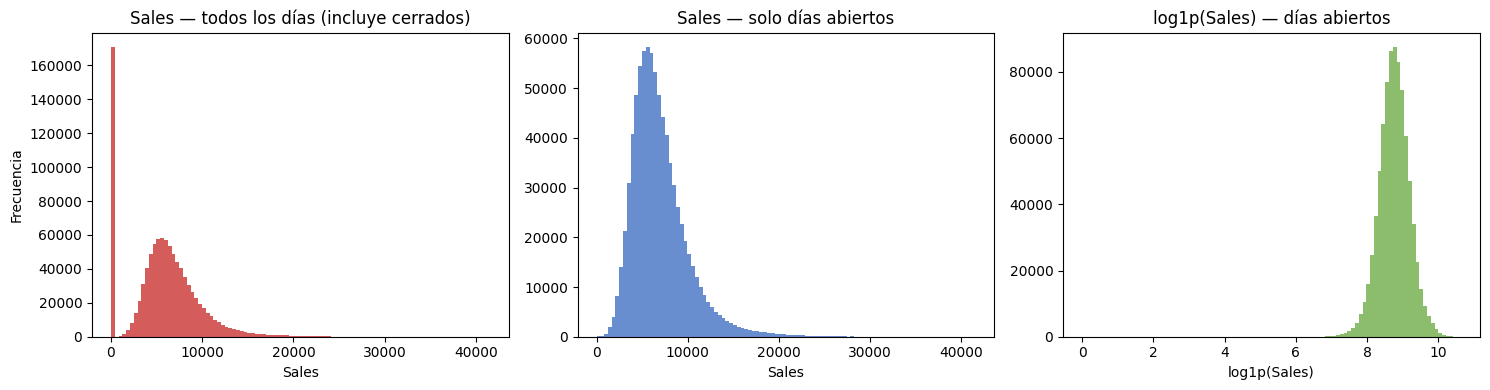

Días con tienda cerrada (Open=0): 170,627 (17.0 %)
Días cerrados con Sales > 0:      0

Estadísticas de Sales (días abiertos):


,count,mean,std,min,25%,50%,75%,max
Sales,830972.000,6955.469,3106.186,0.000,4858.000,6368.000,8360.000,41551.000


In [39]:
train_abierto = train_full[train_full["Open"] == 1].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train_full["Sales"], bins=100, color="#CA3532", alpha=0.8)
axes[0].set_title("Sales — todos los días (incluye cerrados)")
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(train_abierto["Sales"], bins=100, color="#4472C4", alpha=0.8)
axes[1].set_title("Sales — solo días abiertos")
axes[1].set_xlabel("Sales")

axes[2].hist(np.log1p(train_abierto["Sales"]), bins=100, color="#70AD47", alpha=0.8)
axes[2].set_title("log1p(Sales) — días abiertos")
axes[2].set_xlabel("log1p(Sales)")

plt.tight_layout()
plt.show()

n_cerrados = (train_full["Open"] == 0).sum()
n_cerrados_con_ventas = ((train_full["Open"] == 0) & (train_full["Sales"] > 0)).sum()
print(f"Días con tienda cerrada (Open=0): {n_cerrados:,} ({n_cerrados / len(train_full)*100:.1f} %)")
print(f"Días cerrados con Sales > 0:      {n_cerrados_con_ventas}")
print(f"\nEstadísticas de Sales (días abiertos):")
display(train_abierto["Sales"].describe().to_frame().T)

### **5.2 Patrones temporales: día de semana y mes**

Se analiza si las ventas presentan estacionalidad semanal y mensual clara, ya que esto justifica incluir `DayOfWeek` y `Month` como entradas exógenas al modelo.

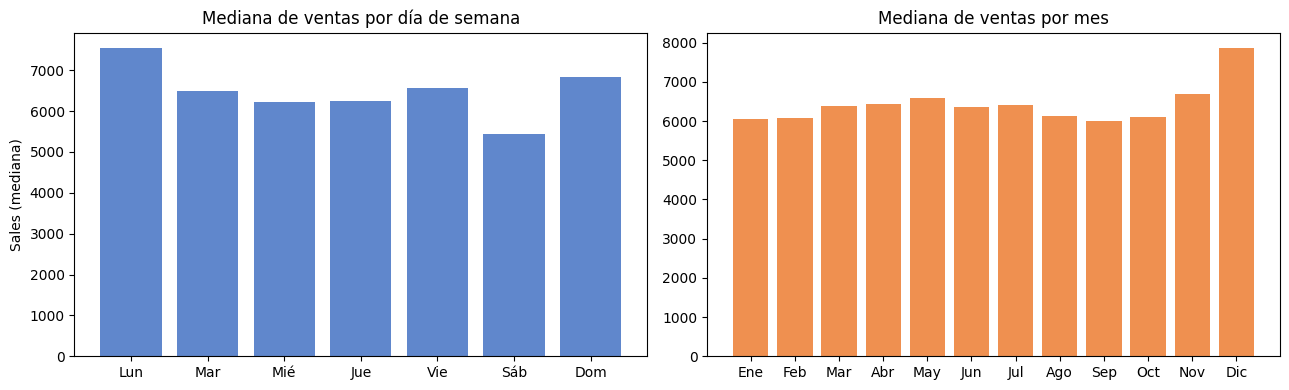

Variación día-semana (max/min): 1.39
Variación mensual  (max/min): 1.31


In [40]:
dias_semana_labels = {1: "Lun", 2: "Mar", 3: "Mié", 4: "Jue", 5: "Vie", 6: "Sáb", 7: "Dom"}
meses_labels = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun",
                7:"Jul",8:"Ago",9:"Sep",10:"Oct",11:"Nov",12:"Dic"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ventas_dia = train_abierto.groupby("DayOfWeek")["Sales"].median()
axes[0].bar(
    [dias_semana_labels[d] for d in ventas_dia.index],
    ventas_dia.values,
    color="#4472C4", alpha=0.85,
)
axes[0].set_title("Mediana de ventas por día de semana")
axes[0].set_ylabel("Sales (mediana)")

ventas_mes = train_abierto.groupby("Month")["Sales"].median()
axes[1].bar(
    [meses_labels[m] for m in ventas_mes.index],
    ventas_mes.values,
    color="#ED7D31", alpha=0.85,
)
axes[1].set_title("Mediana de ventas por mes")

plt.tight_layout()
plt.show()

print("Variación día-semana (max/min):", round(ventas_dia.max() / ventas_dia.min(), 2))
print("Variación mensual  (max/min):", round(ventas_mes.max() / ventas_mes.min(), 2))

### **5.3 Tipo de tienda, surtido y efecto de las promociones**

Se compara la distribución de ventas entre categorías de tienda y se cuantifica el impacto de `Promo` y `Promo2ActiveMonth` para confirmar su relevancia como entradas al modelo.

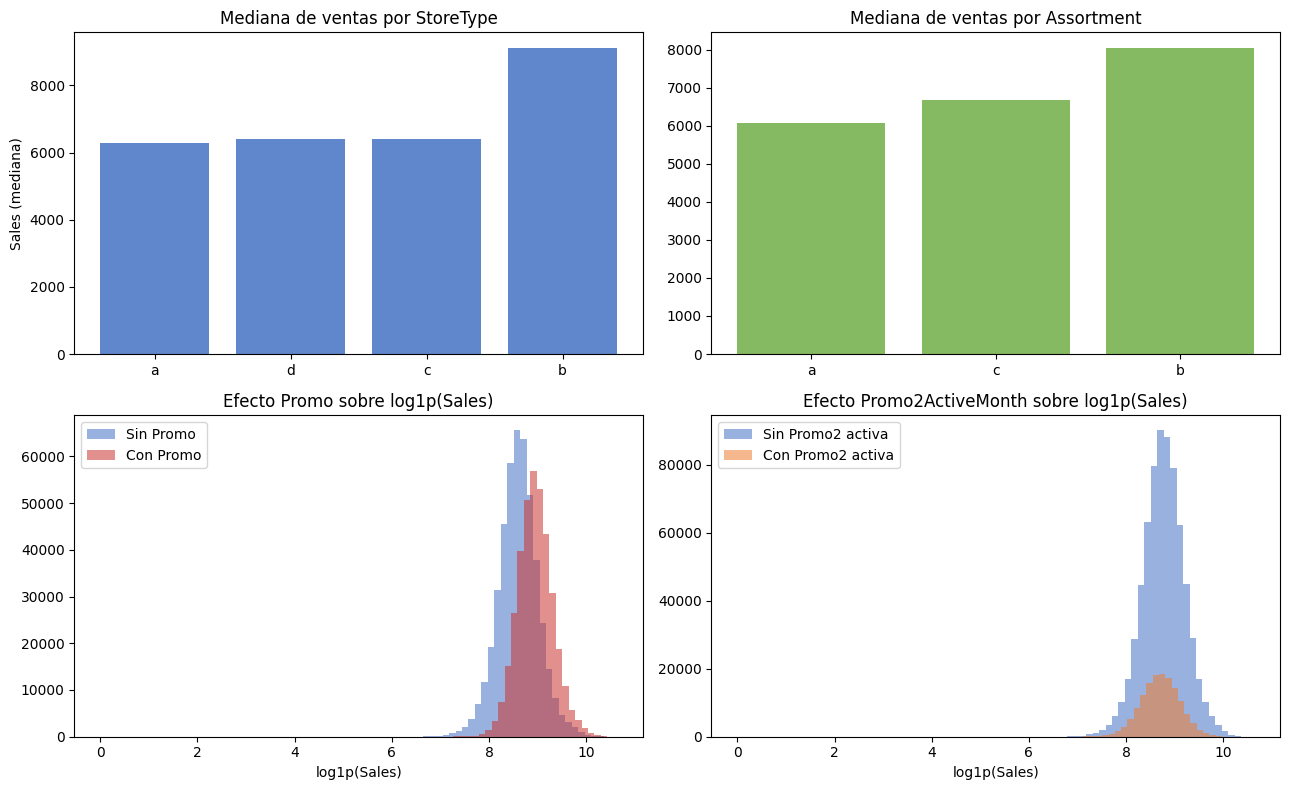

Incremento mediano Promo:             +40.1%
Incremento mediano Promo2ActiveMonth: +-6.3%


In [41]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Ventas por StoreType
mediana_storetype = train_abierto.groupby("StoreType")["Sales"].median().sort_values()
axes[0, 0].bar(mediana_storetype.index, mediana_storetype.values, color="#4472C4", alpha=0.85)
axes[0, 0].set_title("Mediana de ventas por StoreType")
axes[0, 0].set_ylabel("Sales (mediana)")

# Ventas por Assortment
mediana_assort = train_abierto.groupby("Assortment")["Sales"].median().sort_values()
axes[0, 1].bar(mediana_assort.index, mediana_assort.values, color="#70AD47", alpha=0.85)
axes[0, 1].set_title("Mediana de ventas por Assortment")

# Efecto Promo
for promo_val, label, color in [(0, "Sin Promo", "#4472C4"), (1, "Con Promo", "#CA3532")]:
    axes[1, 0].hist(
        np.log1p(train_abierto[train_abierto["Promo"] == promo_val]["Sales"]),
        bins=80, alpha=0.55, label=label, color=color,
    )
axes[1, 0].set_title("Efecto Promo sobre log1p(Sales)")
axes[1, 0].set_xlabel("log1p(Sales)")
axes[1, 0].legend()

# Efecto Promo2ActiveMonth
for val, label, color in [(0, "Sin Promo2 activa", "#4472C4"), (1, "Con Promo2 activa", "#ED7D31")]:
    axes[1, 1].hist(
        np.log1p(train_abierto[train_abierto["Promo2ActiveMonth"] == val]["Sales"]),
        bins=80, alpha=0.55, label=label, color=color,
    )
axes[1, 1].set_title("Efecto Promo2ActiveMonth sobre log1p(Sales)")
axes[1, 1].set_xlabel("log1p(Sales)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

incr_promo = (train_abierto[train_abierto["Promo"]==1]["Sales"].median() /
              train_abierto[train_abierto["Promo"]==0]["Sales"].median() - 1) * 100
incr_promo2 = (train_abierto[train_abierto["Promo2ActiveMonth"]==1]["Sales"].median() /
               train_abierto[train_abierto["Promo2ActiveMonth"]==0]["Sales"].median() - 1) * 100
print(f"Incremento mediano Promo:             +{incr_promo:.1f}%")
print(f"Incremento mediano Promo2ActiveMonth: +{incr_promo2:.1f}%")

### **5.4 Variables de competencia y distribuciones numéricas**

Se analiza la forma de las distribuciones de `CompetitionDistance`, `CompetitionOpenMonths`, `Customers` y `Promo2Weeks` para decidir si alguna requiere transformación logarítmica adicional antes del escalado.

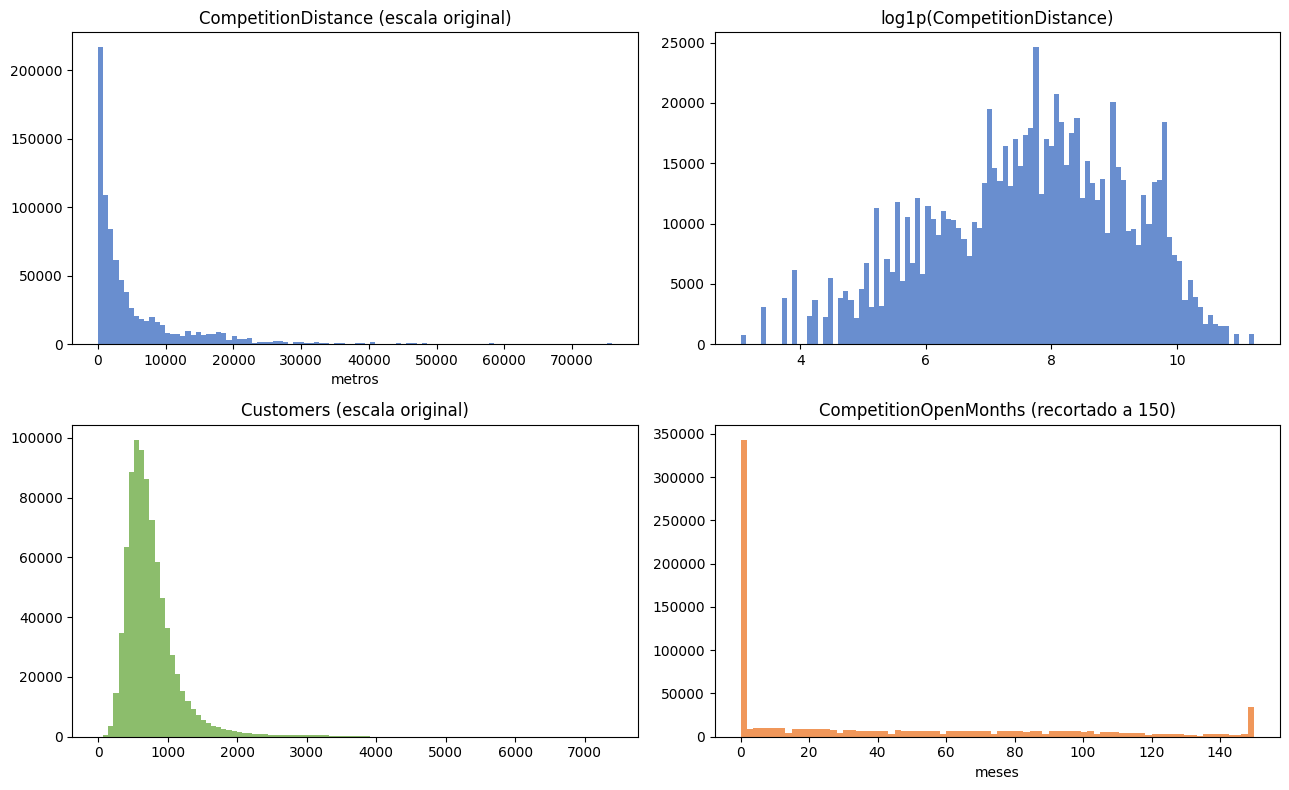

Resumen CompetitionDistance:


,count,mean,std,min,25%,50%,75%,max
CompetitionDistance,830972.000,5450.337,7801.741,20.000,710.000,2330.000,6880.000,75860.000



Resumen Customers:


,count,mean,std,min,25%,50%,75%,max
Customers,830972.000,763.342,401.616,0.000,519.000,676.000,893.000,7388.000


In [42]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].hist(train_abierto["CompetitionDistance"], bins=100, color="#4472C4", alpha=0.8)
axes[0, 0].set_title("CompetitionDistance (escala original)")
axes[0, 0].set_xlabel("metros")

axes[0, 1].hist(np.log1p(train_abierto["CompetitionDistance"]), bins=100, color="#4472C4", alpha=0.8)
axes[0, 1].set_title("log1p(CompetitionDistance)")

axes[1, 0].hist(train_abierto["Customers"], bins=100, color="#70AD47", alpha=0.8)
axes[1, 0].set_title("Customers (escala original)")

axes[1, 1].hist(train_abierto["CompetitionOpenMonths"].clip(0, 150), bins=80, color="#ED7D31", alpha=0.8)
axes[1, 1].set_title("CompetitionOpenMonths (recortado a 150)")
axes[1, 1].set_xlabel("meses")

plt.tight_layout()
plt.show()

print("Resumen CompetitionDistance:")
display(train_abierto["CompetitionDistance"].describe().to_frame().T)
print("\nResumen Customers:")
display(train_abierto["Customers"].describe().to_frame().T)

### **5.5 Correlación entre variables numéricas**

Un mapa de calor permite detectar correlaciones fuertes entre predictores y confirmar cuáles están más relacionados con las ventas.

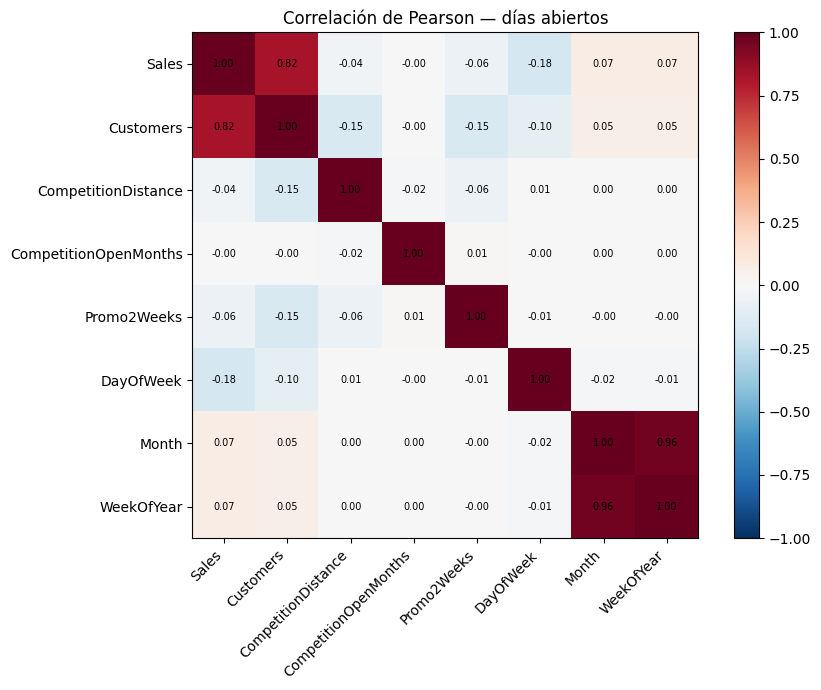

In [43]:
columnas_correlacion = [
    "Sales", "Customers", "CompetitionDistance", "CompetitionOpenMonths",
    "Promo2Weeks", "DayOfWeek", "Month", "WeekOfYear",
]

corr = train_abierto[columnas_correlacion].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(columnas_correlacion)))
ax.set_yticks(range(len(columnas_correlacion)))
ax.set_xticklabels(columnas_correlacion, rotation=45, ha="right")
ax.set_yticklabels(columnas_correlacion)
plt.colorbar(im, ax=ax)

for i in range(len(columnas_correlacion)):
    for j in range(len(columnas_correlacion)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7)

ax.set_title("Correlación de Pearson — días abiertos")
plt.tight_layout()
plt.show()

### **Conclusiones del EDA**

El análisis exploratorio arroja las siguientes observaciones que guiarán directamente las decisiones de preprocesado y modelado:

| Observación | Implicación para el modelo |
|---|---|
| `Sales` fuertemente asimétrica a la derecha | Aplicar `log1p` al target y a la columna Sales en la ventana temporal |
| ~10 % de días con tienda cerrada (Sales = 0) | Los ceros son estructurales, no outliers; el modelo debe verlos en el historial |
| Estacionalidad semanal pronunciada (~2× entre días) | `DayOfWeek` es una entrada exógena relevante; justifica usar embedding |
| Estacionalidad mensual moderada | `Month` útil como entrada exógena; ciclos de ~1 año visibles |
| `StoreType` produce diferencias grandes entre grupos | Justifica embedding de tienda para capturar la identidad de cada una |
| `Promo` incrementa ventas medianas ~20-25 % | Variable exógena de alta señal; debe incluirse en la ventana temporal |
| `CompetitionDistance` muy sesgada → log1p la normaliza | Se aplicará `log1p` antes del StandardScaler |
| `Customers` altamente correlada con `Sales` | Entrada exógena de alta señal (disponible en `test.csv`) |

## <font color="#CA3532"> **6. Escalado**</font>

Las conclusiones del EDA determinan la estrategia de escalado:

1. **`log1p`** sobre `Sales` (target `y` y columna Sales en `X_temporal`) y sobre `CompetitionDistance` en la ventana.
2. **`StandardScaler`** sobre el resto de columnas continuas, ajustado exclusivamente sobre entrenamiento para evitar fuga de información.
3. **Sin escalar**: variables binarias (`Open`, `Promo`, `SchoolHoliday`, `Promo2ActiveMonth`) y códigos categóricos para embeddings.

### **6.1 Transformación log1p sobre el target y Sales en la ventana**

In [44]:
IDX_SALES = columnas_temporales_ventana.index("Sales")
IDX_COMP_DIST = columnas_temporales_ventana.index("CompetitionDistance")

X_temporal_train_sc = X_temporal_train.copy()
X_temporal_val_sc   = X_temporal_val.copy()

# log1p en Sales (endógena en la ventana)
X_temporal_train_sc[:, :, IDX_SALES] = np.log1p(X_temporal_train_sc[:, :, IDX_SALES])
X_temporal_val_sc[:, :, IDX_SALES]   = np.log1p(X_temporal_val_sc[:, :, IDX_SALES])

# log1p en CompetitionDistance (muy sesgada según EDA)
X_temporal_train_sc[:, :, IDX_COMP_DIST] = np.log1p(X_temporal_train_sc[:, :, IDX_COMP_DIST])
X_temporal_val_sc[:, :, IDX_COMP_DIST]   = np.log1p(X_temporal_val_sc[:, :, IDX_COMP_DIST])

# log1p en target
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)

print(f"y_train original — media: {y_train.mean():.1f}, std: {y_train.std():.1f}")
print(f"y_train log1p    — media: {y_train_log.mean():.3f}, std: {y_train_log.std():.3f}")

y_train original — media: 5228.3, std: 3229.5
y_train log1p    — media: 7.192, std: 3.289


### **6.2 StandardScaler sobre columnas continuas de X_temporal**

In [45]:
from sklearn.preprocessing import StandardScaler

# Columnas binarias que NO se escalan (ya en rango [0,1])
COLS_BINARIAS = {"Open", "Promo", "SchoolHoliday", "Promo2ActiveMonth"}

# Índices de columnas continuas en X_temporal (después de log1p ya aplicado)
idx_continuas_temporal = [
    i for i, col in enumerate(columnas_temporales_ventana)
    if col not in COLS_BINARIAS
]
nombres_continuas_temporal = [columnas_temporales_ventana[i] for i in idx_continuas_temporal]

n_train, lb, _ = X_temporal_train_sc.shape
n_val = X_temporal_val_sc.shape[0]

scaler_temporal = StandardScaler()
scaler_temporal.fit(
    X_temporal_train_sc[:, :, idx_continuas_temporal].reshape(-1, len(idx_continuas_temporal))
)

X_temporal_train_sc[:, :, idx_continuas_temporal] = scaler_temporal.transform(
    X_temporal_train_sc[:, :, idx_continuas_temporal].reshape(-1, len(idx_continuas_temporal))
).reshape(n_train, lb, len(idx_continuas_temporal))

X_temporal_val_sc[:, :, idx_continuas_temporal] = scaler_temporal.transform(
    X_temporal_val_sc[:, :, idx_continuas_temporal].reshape(-1, len(idx_continuas_temporal))
).reshape(n_val, lb, len(idx_continuas_temporal))

print(f"Columnas escaladas en X_temporal ({len(idx_continuas_temporal)}):")
print(nombres_continuas_temporal)

Columnas escaladas en X_temporal (9):
['Sales', 'Customers', 'CompetitionDistance', 'CompetitionOpenMonths', 'Promo2Weeks', 'DayOfWeek', 'Month', 'WeekOfYear', 'DayOfYear']


### **6.3 StandardScaler sobre columnas continuas de X_estatico**

In [46]:
# Los primeros 4 campos de X_estatico son códigos para embeddings -> no escalar.
# CompetitionOpen y Promo2 son binarias -> tampoco se escalan.
COLS_EMBEDDING_ESTATICO = {"StoreCode", "StoreTypeCode", "AssortmentCode", "PromoIntervalCode"}
COLS_BINARIAS_ESTATICO = {"CompetitionOpen", "Promo2"}

idx_continuas_estatico = [
    i for i, col in enumerate(columnas_estaticas_ventana)
    if col not in COLS_EMBEDDING_ESTATICO and col not in COLS_BINARIAS_ESTATICO
]
nombres_continuas_estatico = [columnas_estaticas_ventana[i] for i in idx_continuas_estatico]

X_estatico_train_sc = X_estatico_train.copy()
X_estatico_val_sc   = X_estatico_val.copy()

scaler_estatico = StandardScaler()
scaler_estatico.fit(X_estatico_train_sc[:, idx_continuas_estatico])

X_estatico_train_sc[:, idx_continuas_estatico] = scaler_estatico.transform(
    X_estatico_train_sc[:, idx_continuas_estatico]
)
X_estatico_val_sc[:, idx_continuas_estatico] = scaler_estatico.transform(
    X_estatico_val_sc[:, idx_continuas_estatico]
)

print(f"Columnas escaladas en X_estatico ({len(idx_continuas_estatico)}): {nombres_continuas_estatico}")
print(f"Códigos para embeddings (sin escalar): {sorted(COLS_EMBEDDING_ESTATICO)}")
print(f"Binarias estáticas (sin escalar): {sorted(COLS_BINARIAS_ESTATICO)}")

Columnas escaladas en X_estatico (3): ['CompetitionDistance', 'CompetitionOpen', 'Promo2']
Códigos para embeddings (sin escalar): ['AssortmentCode', 'PromoIntervalCode', 'StoreCode', 'StoreTypeCode']


### **6.4 Verificación: arrays listos para el modelo**

In [47]:
resumen_arrays = pd.DataFrame({
    "array": [
        "X_temporal_train_sc", "X_temporal_val_sc",
        "X_estatico_train_sc", "X_estatico_val_sc",
        "y_train_log",         "y_val_log",
    ],
    "shape": [
        X_temporal_train_sc.shape, X_temporal_val_sc.shape,
        X_estatico_train_sc.shape, X_estatico_val_sc.shape,
        y_train_log.shape,         y_val_log.shape,
    ],
    "media": [
        float(X_temporal_train_sc.mean()), float(X_temporal_val_sc.mean()),
        float(X_estatico_train_sc.mean()), float(X_estatico_val_sc.mean()),
        float(y_train_log.mean()),         float(y_val_log.mean()),
    ],
    "std": [
        float(X_temporal_train_sc.std()), float(X_temporal_val_sc.std()),
        float(X_estatico_train_sc.std()), float(X_estatico_val_sc.std()),
        float(y_train_log.std()),         float(y_val_log.std()),
    ],
})
display(resumen_arrays)
print("\nTodos los arrays están listos para ser usados como entradas del modelo neuronal.")

,array,shape,media,std
0,X_temporal_train_sc,"(8580, 28, 13)",0.113,0.890
1,X_temporal_val_sc,"(420, 28, 13)",0.122,0.784
2,X_estatico_train_sc,"(8580, 7)",70.871,213.700
3,X_estatico_val_sc,"(420, 7)",70.871,213.700
4,y_train_log,"(8580,)",7.192,3.289
5,y_val_log,"(420,)",7.451,3.063



Todos los arrays están listos para ser usados como entradas del modelo neuronal.


## <font color="#CA3532"> **7. Baseline persistente**</font>

Antes de entrenar una red neuronal, se define un modelo de referencia sencillo. En series de ventas diarias suele ser razonable usar una persistencia semanal:

\[
Sales(t) = Sales(t-7)
\]

Este baseline permite comprobar si los modelos neuronales aportan mejora real frente a una regla simple basada en el patrón semanal.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def calcular_metricas(y_real, y_pred, nombre):
    return {
        "modelo": nombre,
        "R2": r2_score(y_real, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "MAE": mean_absolute_error(y_real, y_pred),
    }

### **7.1 Predicción persistente a 1 día y a 7 días**

Se calculan dos referencias: una persistencia diaria (`t-1`) y una persistencia semanal (`t-7`). La semanal suele ser más fuerte en este problema porque las ventas dependen mucho del día de la semana.

In [ ]:
if lookback < 7:
    raise ValueError("El baseline semanal necesita lookback >= 7")

idx_sales = columnas_temporales_ventana.index("Sales")

pred_persistente_1d = X_temporal[:, -1, idx_sales]
pred_persistente_7d = X_temporal[:, -7, idx_sales]

mascara_train_np = mascara_train.to_numpy()
mascara_val_np = mascara_val.to_numpy()

pred_persistente_1d_train = pred_persistente_1d[mascara_train_np]
pred_persistente_1d_val = pred_persistente_1d[mascara_val_np]
pred_persistente_7d_train = pred_persistente_7d[mascara_train_np]
pred_persistente_7d_val = pred_persistente_7d[mascara_val_np]

print("pred_persistente_1d_val:", pred_persistente_1d_val.shape)
print("pred_persistente_7d_val:", pred_persistente_7d_val.shape)

### **7.2 Métricas del baseline**

In [ ]:
metricas_baseline = pd.DataFrame([
    calcular_metricas(y_train, pred_persistente_1d_train, "Persistente 1 día - train"),
    calcular_metricas(y_val, pred_persistente_1d_val, "Persistente 1 día - validación"),
    calcular_metricas(y_train, pred_persistente_7d_train, "Persistente 7 días - train"),
    calcular_metricas(y_val, pred_persistente_7d_val, "Persistente 7 días - validación"),
])

metricas_baseline

### **7.3 Comparación visual en validación**

In [ ]:
comparacion_val = metadatos_ventanas.loc[mascara_val_np].copy()
comparacion_val["Sales_real"] = y_val
comparacion_val["Baseline_1d"] = pred_persistente_1d_val
comparacion_val["Baseline_7d"] = pred_persistente_7d_val

tienda_grafica = comparacion_val["Store"].iloc[0]
datos_grafica = comparacion_val[comparacion_val["Store"] == tienda_grafica].sort_values("Date")

plt.figure(figsize=(12, 4))
plt.plot(datos_grafica["Date"], datos_grafica["Sales_real"], label="Real", linewidth=2)
plt.plot(datos_grafica["Date"], datos_grafica["Baseline_1d"], label="Persistente 1 día", alpha=0.75)
plt.plot(datos_grafica["Date"], datos_grafica["Baseline_7d"], label="Persistente 7 días", alpha=0.75)
plt.title(f"Baseline persistente en validación - tienda {tienda_grafica}")
plt.xlabel("Fecha")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

display(comparacion_val.head())